
# En el siguiente script vamos a convertir grados Farenheit a grados Celsius. Todo mediante una red neuronal, de una sola capa y de una sola neurona. Esto es un simil a una regresión lineal, pero con redes neuronales.

In [7]:
#importamos tensorflow para manejar redes neuronales y numpy para manejar arreglos de modo mas simple
import tensorflow as tf
import numpy as np
#matplotlib es para una visualización del entrenamiento de la red neuronal
import matplotlib.pyplot as plt

# Vamos a usar un arreglo de datos de entrada y uno de salida

In [ ]:

#Datos en Celsius (entrada)
celsius = np.array([-40,-10,0,8,15,22,38], dtype=float)

#Datos en Farenheit (salida)
farenheit = np.array([-40, 14, 32, 46, 59, 72, 100], dtype=float)

# Vamos a definir una red neuronal con una sola capa y una sola neurona, no hace falta mas para una regresión tan simple

In [ ]:

capa = tf.keras.layers.Dense(units=1, input_shape=[1])

#El modelo va a trabajar de modo secuencial sobre la red que hemos definido antes, una capa y una neurona
modelo = tf.keras.Sequential([capa])


# Definimos el modelo que va a compilar con un optimizador, en este caso es Adam, con una perdida cuadrada promedio, tipicamente usada en estadistica
# El valor que le damos a Adam es basicamente el paso que debera seguir, para llegar al error cuadratico medio.

In [ ]:


modelo.compile(optimizer=tf.keras.optimizers.Adam(0.1),loss='mean_squared_error')

# Se puede jugar con las "epochs" que son las iteraciones, si uno quiere ver errores puede tomar menos de 150 aprox y si quieres ver el modelo trabajando muy fino debes aumentar el numero de epochs por encima de 200.
# Con 1000 se puede casi visualizar la convergencia de la red neuronal, llega un punto donde no puede mejorar mucho más.

In [ ]:
#
print("Comenzando entrenamiento")
historial = modelo.fit(celsius, farenheit, epochs=1000, verbose= False)
print("El modelo se ha entrenado!")

Comenzando entrenamiento
El modelo se ha entrenado!


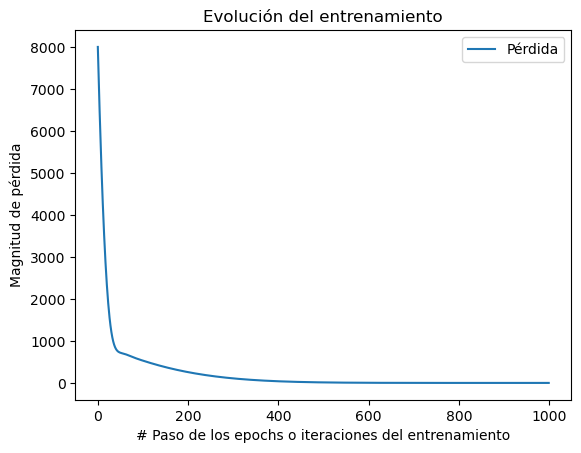

Cuando la tendencia es asintotica es por que al modelo ya le esta costando trabajo mejorar, esto comienza a verse despues de la iteración 200 aprox


In [12]:
#Visualización de las iteraciones de la red neuronal, entre mas epochs o epocas pasen mejor se va a entrenar la red neuronal, este valor suele converger hasta su mejor estado
plt.title("Evolución del entrenamiento")
plt.xlabel("# Paso de los epochs o iteraciones del entrenamiento")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"], label="Pérdida")
plt.legend()
plt.show()

print("Cuando la tendencia es asintotica es por que al modelo ya le esta costando trabajo mejorar, esto comienza a verse despues de la iteración 200 aprox")

Hagamos una predicción:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
El resultado es:[[85.85051]] °Fahrenheit

El resultado bajo la formula °Fahrenheit = 1.8*(°Celsius)+ 32 es:  86.0 Fahrenheit

Con lo que vemos el resultado tiene un margen de error pequeño de: [[0.00173825]] %


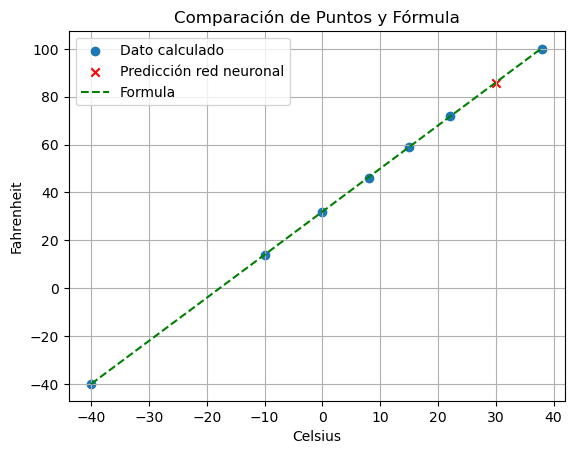

In [13]:
#Hagamos una prueba con nuestra predicción
print("Hagamos una predicción:")
prueba = float(input("Ingrese la temperatura en grados Celsius: "))
resultado = modelo.predict(np.array([prueba]))
print(f"El resultado es:{resultado} °Fahrenheit")

farenh= prueba*1.8+32
err= resultado/farenh
print(f"\nEl resultado bajo la formula °Fahrenheit = 1.8*(°Celsius)+ 32 es: ", farenh, "Fahrenheit")
print(f"\nCon lo que vemos el resultado tiene un margen de error pequeño de:", 1-err,"%")


#Rango para la formulación
celsius_formula = np.linspace(min(celsius), max(celsius), 100)
farenheit_formula = celsius_formula * 1.8 + 32

#Puntos calculador por medio de la formula
plt.scatter(celsius, farenheit, label='Dato calculado')

#Mostrar el punto de predicción por la red neuronal
plt.scatter(prueba, resultado, color='red', label='Predicción red neuronal',marker = 'x')

#Mostrar la linea de la formula
plt.plot(celsius_formula, farenheit_formula, color='green', linestyle='--', label='Formula')

plt.xlabel("Celsius")
plt.ylabel("Fahrenheit")
plt.title("Comparación de Puntos y Fórmula")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
print("Veamos que variables internas produce el modelo")
print(capa.get_weights())

#Que son muy cercanos a la formulación "°Fahrenheit = 1.8*(°Celsius)+ 32"
#Así podemos decir que nuestro programa ha sido un exito!

Veamos que variables internas produce el modelo
[array([[1.7984242]], dtype=float32), array([31.897785], dtype=float32)]


# Podemos ver que los valores son muy cercanos a la formulación:

$°Fahrenheit = 1.8*(°Celsius)+ 32$